# Train YOLO Model on BePLi Dataset

## Install Dependencies

We use UV to manage packages because it is reproducible.

### NVIDIA GPU (CUDA)

torch-cuda will be automatically installed for windows users.

### Macbook (MPS)

No specific torch version required.

### Intel GPU (XPU)

Supported for Intel Arc and newer GPUs.

torch-xpu will be automatically installed for linux users.

### CPU Only

Not recommended.

```bash
uv sync
```

## Directory Tree

BePLi Dataset

- plastic_coco/


## Set up torch

### NVIDIA GPU (CUDA)


In [ ]:

import torch

print(f"PyTorch Version: {torch.__version__}")
# You want to see something like: 2.9.1+cu121
# If you see just '2.9.1', it is still the CPU version.

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")

device_str = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from ultralytics import YOLO

PyTorch Version: 2.5.1+cu124
CUDA Available: True
CUDA Available: True
Current GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


## Intel GPU (XPU)

In [1]:
import torch

print(f"PyTorch Version: {torch.__version__}")

print(f"XPU Available: {torch.xpu.is_available()}")

if torch.xpu.is_available():
    print(f"Current GPU: {torch.xpu.get_device_name(0)}")

device_str = 'xpu' if torch.xpu.is_available() else 'cpu'
device = torch.device('xpu' if torch.xpu.is_available() else 'cpu')

PyTorch Version: 2.9.1+xpu
XPU Available: True
Current GPU: Intel(R) Arc(TM) Graphics


In [2]:
# Ultralytics has hardcoded CUDA calls that break on XPU
# Monkey-patch functions to work with XPU
import torch
from ultralytics import YOLO
import ultralytics.engine.trainer as trainer_module
import ultralytics.engine.validator as validator_module
import ultralytics.utils.torch_utils as torch_utils_module
import ultralytics.utils.checks as checks_module
import ultralytics.utils as utils_module
import gc

def _get_memory_xpu(self, fraction=False):
    """XPU-compatible memory getter."""
    memory = torch.xpu.memory_reserved() if hasattr(torch.xpu, 'memory_reserved') else 0
    if fraction:
        return 0.1  # Return low fraction to skip memory clearing
    return memory / 2**30

def _clear_memory_xpu(self, threshold=0.5):
    """XPU-compatible memory clearing."""
    gc.collect()
    if hasattr(torch.xpu, 'empty_cache'):
        torch.xpu.empty_cache()

# Patch the select_device function to handle XPU
_original_select_device = torch_utils_module.select_device

def select_device_xpu(device="", newline=False, verbose=True):
    """XPU-aware device selector."""
    device_str = str(device).strip().lower()
    if device_str == "xpu" or (hasattr(device, 'type') and device.type == 'xpu'):
        if torch.xpu.is_available():
            return torch.device('xpu')
    return _original_select_device(device, newline, verbose)

# Patch check_amp to avoid CUDA-only probing on non-CUDA builds (XPU/CPU)
_original_check_amp = checks_module.check_amp

def check_amp_safe(model):
    try:
        if hasattr(torch, "xpu") and torch.xpu.is_available():
            return False
        if not torch.cuda.is_available():
            return False
    except Exception:
        return False
    return _original_check_amp(model)

checks_module.check_amp = check_amp_safe
# BaseTrainer imports check_amp into its module namespace, so patch there too
trainer_module.check_amp = check_amp_safe

# Apply all patches
trainer_module.BaseTrainer._get_memory = _get_memory_xpu
trainer_module.BaseTrainer._clear_memory = _clear_memory_xpu

# Patch select_device everywhere it's imported
torch_utils_module.select_device = select_device_xpu
trainer_module.select_device = select_device_xpu
validator_module.select_device = select_device_xpu

# Also patch in ultralytics.utils (where it might be imported from)
utils_module.torch_utils.select_device = select_device_xpu

## Data Preparation

In [16]:
import json
from pathlib import Path

# Configuration
DATASET_ROOT = Path('plastic_coco')
ANNOTATION_DIR = DATASET_ROOT / 'annotation'
LABELS_DIR = DATASET_ROOT / 'labels'

# Mapping your file names to the subset folder names
# keys = json filenames (without extension), values = folder names
SUBSETS = {
    'train': 'train',
    'val': 'val',
    'test': 'test'
}

def convert_to_yolo(bbox, img_w, img_h):
    # COCO bbox: [x_min, y_min, width, height]
    x, y, w, h = bbox
    
    # YOLO bbox: [x_center, y_center, width, height] (Normalized 0-1)
    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    w_norm = w / img_w
    h_norm = h / img_h
    
    return [x_center, y_center, w_norm, h_norm]

def process_subset(subset_name, folder_name):
    json_file = ANNOTATION_DIR / f'{subset_name}.json'
    output_dir = LABELS_DIR / folder_name
    
    if not json_file.exists():
        print(f"Skipping {subset_name}: {json_file} not found.")
        return

    output_dir.mkdir(parents=True, exist_ok=True)
    
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    # Create image lookup dict
    images = {img['id']: img for img in data['images']}
    
    # Prepare categories (classes)
    # Ensure class IDs start at 0 for YOLO
    categories = {cat['id']: cat['name'] for cat in data['categories']}
    # If your COCO IDs don't start at 0, you might need to remap them here.
    # Usually standard COCO is 1-indexed, YOLO needs 0-indexed.
    cat_id_map = {old_id: i for i, old_id in enumerate(sorted(categories.keys()))}
    
    print(f"Processing {subset_name}...")
    print(f"Classes found: {[categories[id] for id in sorted(categories.keys())]}")

    # Process annotations
    for ann in data['annotations']:
        image_id = ann['image_id']
        img_info = images[image_id]
        
        filename = img_info['file_name']
        # Handle cases where filename might include subfolders
        file_stem = Path(filename).stem
        
        img_w = img_info['width']
        img_h = img_info['height']
        
        # Convert BBox
        bbox = convert_to_yolo(ann['bbox'], img_w, img_h)
        class_id = cat_id_map[ann['category_id']]
        
        label_line = f"{class_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n"
        
        # Write to txt file
        txt_path = output_dir / f"{file_stem}.txt"
        with open(txt_path, 'a') as f_out:
            f_out.write(label_line)

    print(f"Finished {subset_name}. Labels saved to {output_dir}")
    return [categories[id] for id in sorted(categories.keys())]

# Run conversion
class_names = []
for json_name, folder_name in SUBSETS.items():
    names = process_subset(json_name, folder_name)
    if names: class_names = names

print("\n--- Done! ---")
print("Use these class names in your YAML file:")
print(class_names)

Processing train...
Classes found: ['plastic_litter']
Finished train. Labels saved to plastic_coco/labels/train
Processing val...
Classes found: ['plastic_litter']
Finished val. Labels saved to plastic_coco/labels/val
Processing test...
Classes found: ['plastic_litter']
Finished test. Labels saved to plastic_coco/labels/test

--- Done! ---
Use these class names in your YAML file:
['plastic_litter']


## Train

In [17]:
model = YOLO('yolov8n.pt')  # load a pretrained model (recommended for training)

# Ultralytics uses AMP auto-checks that hard-require CUDA; disable AMP on XPU/CPU builds
amp_flag = False if device_str in {'xpu', 'cpu'} else True

model = YOLO('yolov8n.pt')  # load a pretrained model (nano version)

# Train the model
results = model.train(
    data='plastic_coco/data.yaml', 
    epochs=2, 
    imgsz=640, 
    # batch=16,
    project='plastic_project', # Name of the folder where results will be saved
    name='run1',                # Name of the sub-folder
    device=device_str,
    amp=amp_flag,
)


engine/trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=plastic_coco/data.yaml, degrees=0.0, deterministic=True, device=xpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=run13, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=plastic_project, rect=False, resume=False, re

## Test


image 1/1 /home/kris/Documents/projects/ai-plastic-spotter/train/variety_trash.jpeg: 352x640 17 plastic_litters, 40.1ms
Speed: 1.2ms preprocess, 40.1ms inference, 0.6ms postprocess per image at shape (1, 3, 352, 640)
['plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter'] tensor([0.9250, 0.9068, 0.8511, 0.7863, 0.7253, 0.6946, 0.6655, 0.6476, 0.6475, 0.6228, 0.6162, 0.6106, 0.5990, 0.5812, 0.5711, 0.5594, 0.5332])


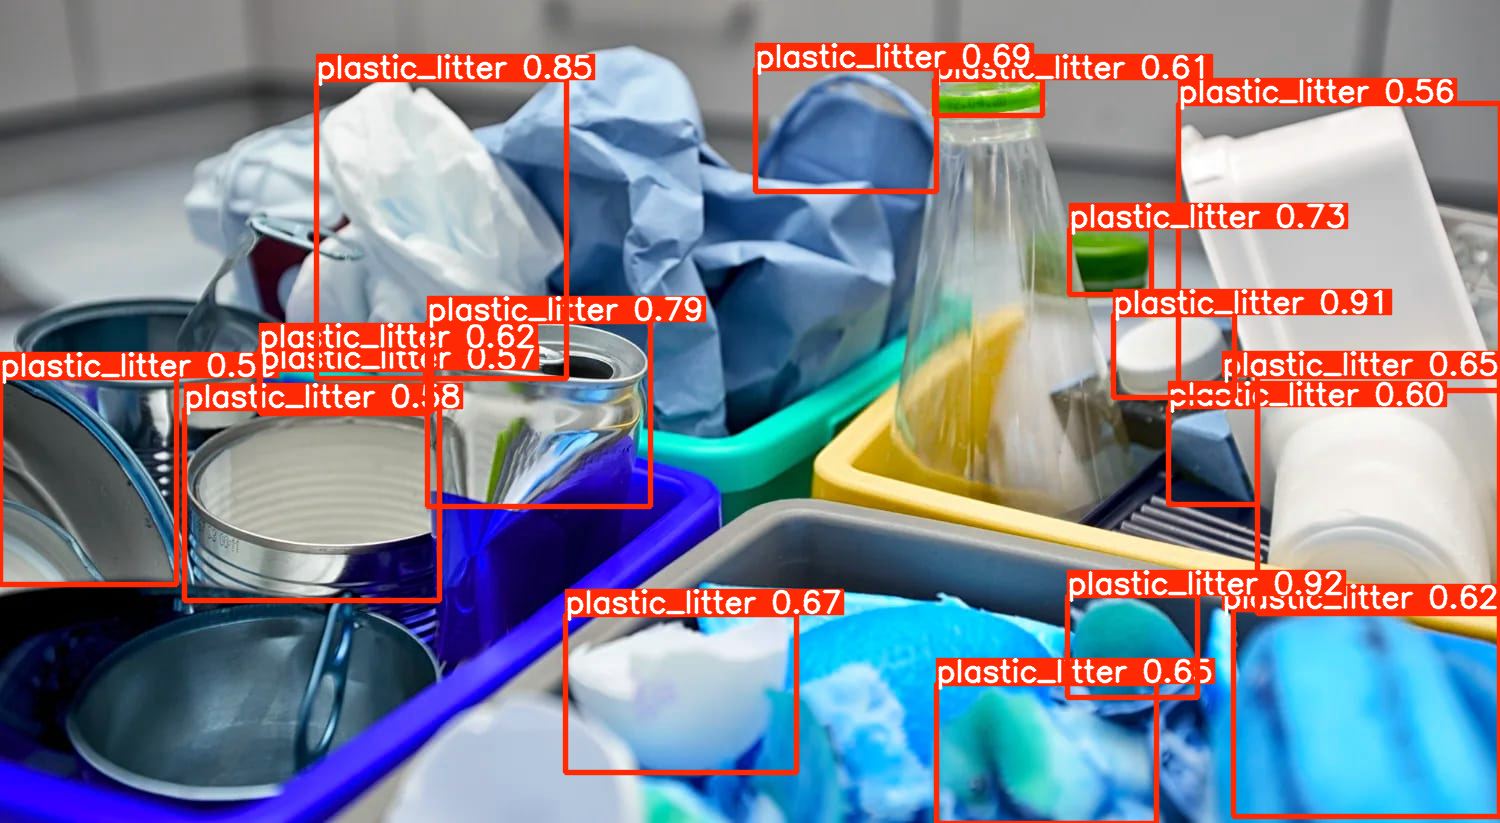

In [ ]:
from pathlib import Path
from PIL import Image

best_weights = Path('plastic_project/run13/weights/best.pt')

if not best_weights.exists():
    raise FileNotFoundError(f"{best_weights} not found; rerun training or adjust the path.")

test_image = Path('variety_trash.jpeg')
if not test_image.exists():
    raise FileNotFoundError(f"{test_image} not found; place the sample image alongside the notebook.")

infer_model = YOLO(str(best_weights))
results = infer_model(test_image, conf=0.5)  # predict on an image

# print(result)
# Access the results
for result in results:
    im_bgr = result.plot()
    xywh = result.boxes.xywh  # center-x, center-y, width, height
    xywhn = result.boxes.xywhn  # normalized
    xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
    xyxyn = result.boxes.xyxyn  # normalized
    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
    confs = result.boxes.conf  # confidence score of each box

    print(names, confs)

    # Display the test image that was classified
    from IPython.display import display
    display(Image.fromarray(im_bgr))